In [1]:
import numpy as np
import time
import timeit
from pathlib import Path
import os
import sys
import math
from tkinter import font
current_dir = os.getcwd()
folder_b_path = os.path.abspath(os.path.join(current_dir, "../Raw_python_"))

if folder_b_path not in sys.path:
    sys.path.append(folder_b_path)

from MNIST_import import MnistDataloader

import matplotlib.pyplot as plt
import torch
import numpy as np 
import torch.nn as nn
import seaborn as sns
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.utils import shuffle


Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1


In [2]:
training_images_filepath = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\train-images-idx3-ubyte\train-images-idx3-ubyte"
training_labels_filepath = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\train-labels-idx1-ubyte\train-labels-idx1-ubyte"
test_labels_filepath     = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\t10k-labels-idx1-ubyte\t10k-labels-idx1-ubyte" 
test_images_filepath     = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\t10k-images-idx3-ubyte\t10k-images-idx3-ubyte"
dataloader = MnistDataloader(
    training_images_filepath,
    training_labels_filepath,
    test_images_filepath,
    test_labels_filepath,
)
(x_train, y_train), (x_test, y_test) = dataloader.load_data()
x_train = torch.from_numpy(x_train)
y_train = torch.from_numpy(y_train)
x_test = torch.from_numpy(x_test)
y_test = torch.from_numpy(y_test)
print(y_test.shape)
x_train = torch.reshape(x_train, (len(x_train), -1)) / 255.0
x_test = torch.reshape(x_test, (len(x_test), -1)) / 255.0
print(y_test.shape)
x_train = torch.cat((x_train, torch.ones(len(x_train), 1)), dim=1)
x_test  = torch.cat((x_test,  torch.ones(len(x_test), 1)), dim=1) # Taking the image arrays and appending 1s as the bias multiplication constant.
x_train, y_train = shuffle(x_train, y_train, random_state=42) # Shuffling training data, 42 seems to be a seed value that you want to keep consistent, but the actual math might be incredibly weird.
print(type(x_train))
print(np.shape(x_train))


C:\Users\User\AppData\Local\Temp\ipykernel_26124\1469912995.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  x_train = torch.from_numpy(x_train)


torch.Size([10000])
torch.Size([10000])
<class 'torch.Tensor'>
torch.Size([60000, 785])


In [3]:
output_layer_size = 10
numLayers = 1 # Number of connecting layers from the input to output.

def instantiate_solution_vectors():
    y_train_t = torch.asarray(y_train, dtype=torch.long)
    return torch.nn.functional.one_hot(y_train_t, num_classes=10)

execution_time = timeit.timeit(instantiate_solution_vectors, number=1000)
print(f"Total time for 1,000 runs: {execution_time:.6f} seconds")
d = instantiate_solution_vectors()
print("d shape: " + str(d.shape))

# Initialize size of first hidden layer of the neural network
layer_1_size = len(x_train[0])  # Size of the first hidden layer is equal to the number of pixels in the input image + an extra weight for a bias term (28x28 + 1 = 785)
# Find a method for initializing the weights of the neural network. Bounds, based on Le Cun (1986) [-2.4/F, 2.4/F] or [-2.4/sqrt(F), 2.4/sqrt(F)]
layer_1_weight_range = 2.4 / math.sqrt(layer_1_size) # Le Cun (1986) weight initialization bounds
weights = torch.empty(size=(numLayers, output_layer_size, layer_1_size)).uniform_(-layer_1_weight_range, layer_1_weight_range)  # Initialize weights for the first hidden layer
print("Weights numpy shape: " + str(np.shape(weights)))

# Compute the number of dot product between the input and the weights of the first hidden layer for each neuron. Time this process to understand how scalable the neural network is.

# Pass each of the neuron dot products through the scaled hyperbolic tangent function to get the output of the first hidden layer.
# Time this process to understand how scalable the neural network is.

print("Layer 1 Size:", layer_1_size)

data_folder = Path(r"C:\Users\User\OneDrive\Desktop\ML_number_reader_1st_paper_tests\Beginning_ML_computerVision\MNIST_digit_reader_1st_attempt\python_\Data")
error_file_path = data_folder / "error_file.txt"
grad_C = torch.zeros((output_layer_size, layer_1_size))  # Initialize the gradient of the cost function with respect to the weights of the first layer

alpha = 0.0001 # Learning rate
epochs = 4 # Number of iterations of SGD
# Variables for the scaled hyperbolic tangent function
A = 1.7159
S = 2/3
SA = S*A

# Create the error file if it does not exist
error_file_path.touch(exist_ok=True)
error_file_path.write_text("")   # reset before starting a new full training run

with open(error_file_path, "a") as file:
    for z in range(epochs):
        start = time.time()
        for c in range(len(x_train)):
            input_vector = x_train[c]  # Convert the input image to a vector
            #print("input vector shape: " + str(input_vector.shape))
            #print(np.shape(input_vector))
            #print(type(input_vector))
            # For each datapoint in the training set, compute the dot prdouct between the input image and the weights of the first hidden layer, 
            # and then pass the result through the scaled hyperbolic tangent function to get the output of the first hidden layer.
            net_input = weights[0] @ input_vector  # As it turns out, the output layer cell input ( a column vector ), is a dot product of the weight matrix rows. The column output is similar a matrix-vector multiplication then
            #print(type(net_input))
            #print("net input shape: " + str(net_input.shape))
            output_layer = A * torch.tanh(S * net_input) # Compute the output of the first hidden layer for the first training image
            #print("output layer shape: " + str(output_layer.shape))
            #print((output_layer - d[c]).shape)
            grad_C = torch.outer(torch.multiply((output_layer - d[c]), SA * torch.cosh(S * net_input)**-2), input_vector)
            #print("grad_C shape: " + str(np.shape(grad_C)))
            weights[0] = weights[0] - alpha * grad_C  # Update the weights of the input to output layer using the negative gradient of the cost function, with a prop. const. alpha (learning rate) to control the step size of the update.
        file.write(str(torch.sum((output_layer - d[c]) ** 2) / 2) + "\n")   # Compute the error between the output of the first hidden layer and the expected output for the first training image
        # Compute the gradient of the cost function with respect to the weights of the first hidden layer ( This is a matrix )
        file.write("New Epoch " + str(z) + "\n\n")  # Add a newline after each epoch
        file.flush() # Save the file after each epoch to ensure that the data is not lost in case of a crash or interruption.
        print("Time for Epoch", z, ":", time.time() - start)

Total time for 1,000 runs: 1.303672 seconds
d shape: torch.Size([60000, 10])
Weights numpy shape: torch.Size([1, 10, 785])
Layer 1 Size: 785
Time for Epoch 0 : 8.316321611404419
Time for Epoch 1 : 7.58953070640564
Time for Epoch 2 : 7.470306158065796
Time for Epoch 3 : 8.494628190994263


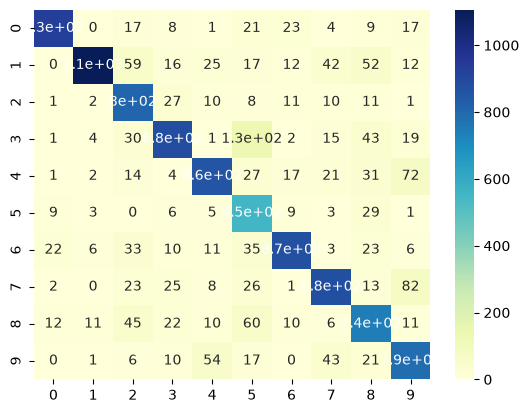

In [4]:
confusion_matrix = [[0 for _ in range(len(output_layer))] for _ in range(len(output_layer))]
correct = 0
for c in range(len(x_test)):
    input_vector = x_test[c]  # Convert the input image to a vector
    net_input = weights[0] @ input_vector
    output_layer = A * torch.tanh(S * net_input)  # Compute the output of the first hidden layer for the first training image
    #print(output_layer.shape)
    output_key = torch.argmax(output_layer).item()
    if output_key == y_test[c]:
        confusion_matrix[y_test[c]][y_test[c]] += 1
        correct += 1
    else:
        confusion_matrix[output_key][y_test[c]] += 1

sns.heatmap(confusion_matrix, annot=True, cmap="YlGnBu", annot_kws={"size": 10})
error = correct/len(x_test)
plt.show()

In [5]:
print("Test Dataset Accuracy: " + str(error))

Test Dataset Accuracy: 0.8416


In [6]:
output_layer_size = 10
numLayers = 1 # Number of connecting layers from the input to output.
alpha = 0.0001 # Learning rate
epochs = 4 # Number of iterations of SGD
# Variables for the scaled hyperbolic tangent function
A = 1.7159
S = 2/3
SA = S*A

def instantiate_solution_vectors():
    y_train_t = torch.asarray(y_train, dtype=torch.long)
    return torch.nn.functional.one_hot(y_train_t, num_classes=10)

d = instantiate_solution_vectors()

# Initialize size of first hidden layer of the neural network
layer_1_size = len(x_train[0])  # Size of the first hidden layer is equal to the number of pixels in the input image + an extra weight for a bias term (28x28 + 1 = 785)
# Method for initializing the weights of the neural network. Bounds, based on Le Cun (1986) [-2.4/F, 2.4/F] or [-2.4/sqrt(F), 2.4/sqrt(F)]
layer_1_weight_range = 2.4 / math.sqrt(layer_1_size) # Le Cun (1986) weight initialization bounds
weights = (torch.rand(10, 785, dtype=torch.float32) * 2 - 1) * layer_1_weight_range
optimizer = torch.optim.SGD([weights], lr=alpha)
weights.requires_grad_(True)

data_folder = Path(r"C:\Users\User\OneDrive\Desktop\ML_number_reader_1st_paper_tests\Beginning_ML_computerVision\MNIST_digit_reader_1st_attempt\python_\Data")
error_file_path = data_folder / "error_file.txt"
# Create the error file if it does not exist
error_file_path.touch(exist_ok=True)
error_file_path.write_text("")   # reset before starting a new full training run


optimizer = torch.optim.SGD([weights], lr=alpha)
with open(error_file_path, "a") as file:
    for z in range(epochs):
        start = time.time()
        for c in range(len(x_train)):
            optimizer.zero_grad()                        # replaces weights.grad.zero_()
            net_input = weights @ x_train[c]
            # For each datapoint in the training set, compute the dot prdouct between the input image and the weights of the first hidden layer, 
            # and then pass the result through the scaled hyperbolic tangent function to get the output of the first hidden layer.
            output_layer = A * torch.tanh(S * net_input)
            cost = torch.sum((output_layer - d[c])**2) / 2
            cost.backward()
            optimizer.step()                             # replaces the manual weights -= alpha*weights.grad
            file.write(str(cost.item()) + "\n")
        # Compute the gradient of the cost function with respect to the weights of the first hidden layer ( This is a matrix )
        file.write("New Epoch " + str(z) + "\n\n")  # Add a newline after each epoch
        file.flush() # Save the file after each epoch to ensure that the data is not lost in case of a crash or interruption.
        print("Time for Epoch", z, ":", time.time() - start)

Time for Epoch 0 : 29.262818574905396
Time for Epoch 1 : 29.633594036102295
Time for Epoch 2 : 32.06185698509216
Time for Epoch 3 : 32.25474309921265


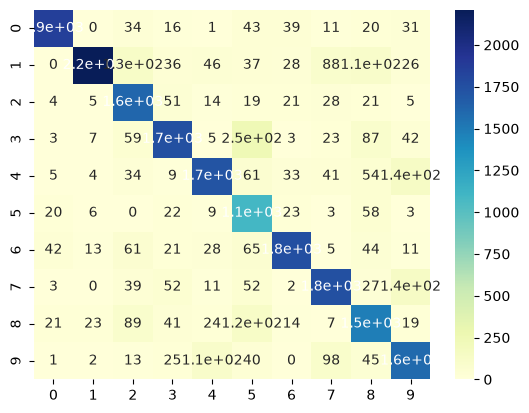

In [7]:
correct = 0
for c in range(len(x_test)):
    input_vector = x_test[c]  # Convert the input image to a vector
    net_input = weights @ input_vector
    output_layer = A * torch.tanh(S * net_input)  # Compute the output of the first hidden layer for the first training image
    #print(output_layer.shape)
    output_key = torch.argmax(output_layer).item()
    if output_key == y_test[c]:
        confusion_matrix[y_test[c]][y_test[c]] += 1
        correct += 1
    else:
        confusion_matrix[output_key][y_test[c]] += 1

sns.heatmap(confusion_matrix, annot=True, cmap="YlGnBu", annot_kws={"size": 10})
error = correct/len(x_test)
plt.show()

In [8]:
print("Test Dataset Accuracy: " + str(error))

Test Dataset Accuracy: 0.8402
